In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import pickle
import gc
import warnings
warnings.filterwarnings('ignore')

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU available: {gpus[0]}")
else:
    print("No GPU found — running on CPU")

plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4


GPU available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [6]:
core_path    = os.getcwd()
orbital_df = pd.read_pickle(os.path.join(core_path, 'data/lvl3/orbital_df.pkl'))

FEATURES_A = ['a_p', 'e_p', 'sin_i_p', 'g', 's']
FEATURES_B = ['a_p', 'e_p', 'sin_i_p', 'g', 's',
              'rms_a', 'rms_e', 'rms_sin_i', 'LCE']

y = orbital_df['is_family_member'].astype(int).values

dl_results = {}

In [7]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}

print(f"Class weights: background={class_weights_arr[0]:.3f}, family={class_weights_arr[1]:.3f}")

Class weights: background=0.643, family=2.251


In [8]:
def build_dense_model(input_dim, layers_config, dropout_rate=0.3, learning_rate=1e-3):
    """
    layers_config: list of units per hidden layer
    e.g. [256, 128, 64] → 3 hidden layers
    """
    inputs = keras.Input(shape=(input_dim,))
    x      = inputs

    for units in layers_config:
        x = layers.Dense(units, activation='relu',
                         kernel_initializer='he_normal',
                         kernel_regularizer=keras.regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(name='auc')]
    )
    return model

In [9]:
EPOCHS     = 50
BATCH_SIZE = 2048   # large batch — 1M dataset benefits from this

for feat_name, features in [
    ('Set_A_orbital', FEATURES_A),
    ('Set_B_full',    FEATURES_B),
]:
    print(f"\n{'='*55}")
    print(f"Feature {feat_name}")
    print(f"{'='*55}")

    X = orbital_df[features].values

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
    )

    # Scale
    scaler  = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    print(f"Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}")

    # Build model
    model = build_dense_model(
        input_dim=len(features),
        layers_config=[512, 256, 128, 64],
        dropout_rate=0.3,
        learning_rate=1e-3
    )
    model.summary()

    # Callbacks
    cb_list = [
        callbacks.EarlyStopping(
            monitor='val_auc', patience=8,
            restore_best_weights=True, mode='max'
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5,
            patience=4, min_lr=1e-6, mode='max', verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=os.path.join(results_path, f'05a_iv_best_{feat_name}.keras'),
            monitor='val_auc', save_best_only=True, mode='max', verbose=0
        )
    ]

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=cb_list,
        verbose=1
    )

    # Evaluate
    y_proba = model.predict(X_test, batch_size=BATCH_SIZE).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    print(f"\n=== DL Dense Binary — {feat_name} ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    dl_results[feat_name] = {
        'history': history.history,
        'scaler': scaler,
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc,
        'y_pred': y_pred, 'y_proba': y_proba, 'y_test': y_test,
        'features': features
    }

    del model
    keras.backend.clear_session()
    gc.collect()


Feature Set_A_orbital
Train : 747,532 | Val : 83,060 | Test : 207,649


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,457 (701.00 KB)

 Trainable params: 177,537 (693.50 KB)

...

 40/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5525 - auc: 0.6050 - loss: 0.9522 - precision: 0.2760 - recall: 0.6164

I0000 00:00:1779545961.255097    5823 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_compare_multiply_reduce_fusion', 8 bytes spill stores, 8 bytes spill loads



355/366 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6188 - auc: 0.6978 - loss: 0.8226 - precision: 0.3299 - recall: 0.6848

I0000 00:00:1779545962.967731    5827 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_169799__.55


366/366 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.6590 - auc: 0.7513 - loss: 0.7510 - precision: 0.3651 - recall: 0.7242 - val_accuracy: 0.7625 - val_auc: 0.8321 - val_loss: 0.6073 - val_precision: 0.4758 - val_recall: 0.6808 - learning_rate: 0.0010
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7252 - auc: 0.8256 - loss: 0.6199 - precision: 0.4343 - recall: 0.7844 - val_accuracy: 0.7860 - val_auc: 0.8694 - val_loss: 0.5401 - val_precision: 0.5119 - val_recall: 0.7817 - learning_rate: 0.0010
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7629 - auc: 0.8619 - loss: 0.5417 - precision: 0.4802 - recall: 0.8152 - val_accuracy: 0.7976 - val_auc: 0.9055 - val_loss: 0.4913 - val_precision: 0.5265 - val_recall: 0.8825 - learning_rate: 0.0010
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7849 - auc: 0.8839 - loss: 0.4927 - precision: 0.5095 - recall: 0.8381 - val_accuracy: 0.8034 - val_auc: 0.9186 - val_loss: 0.4634 - val_precisio

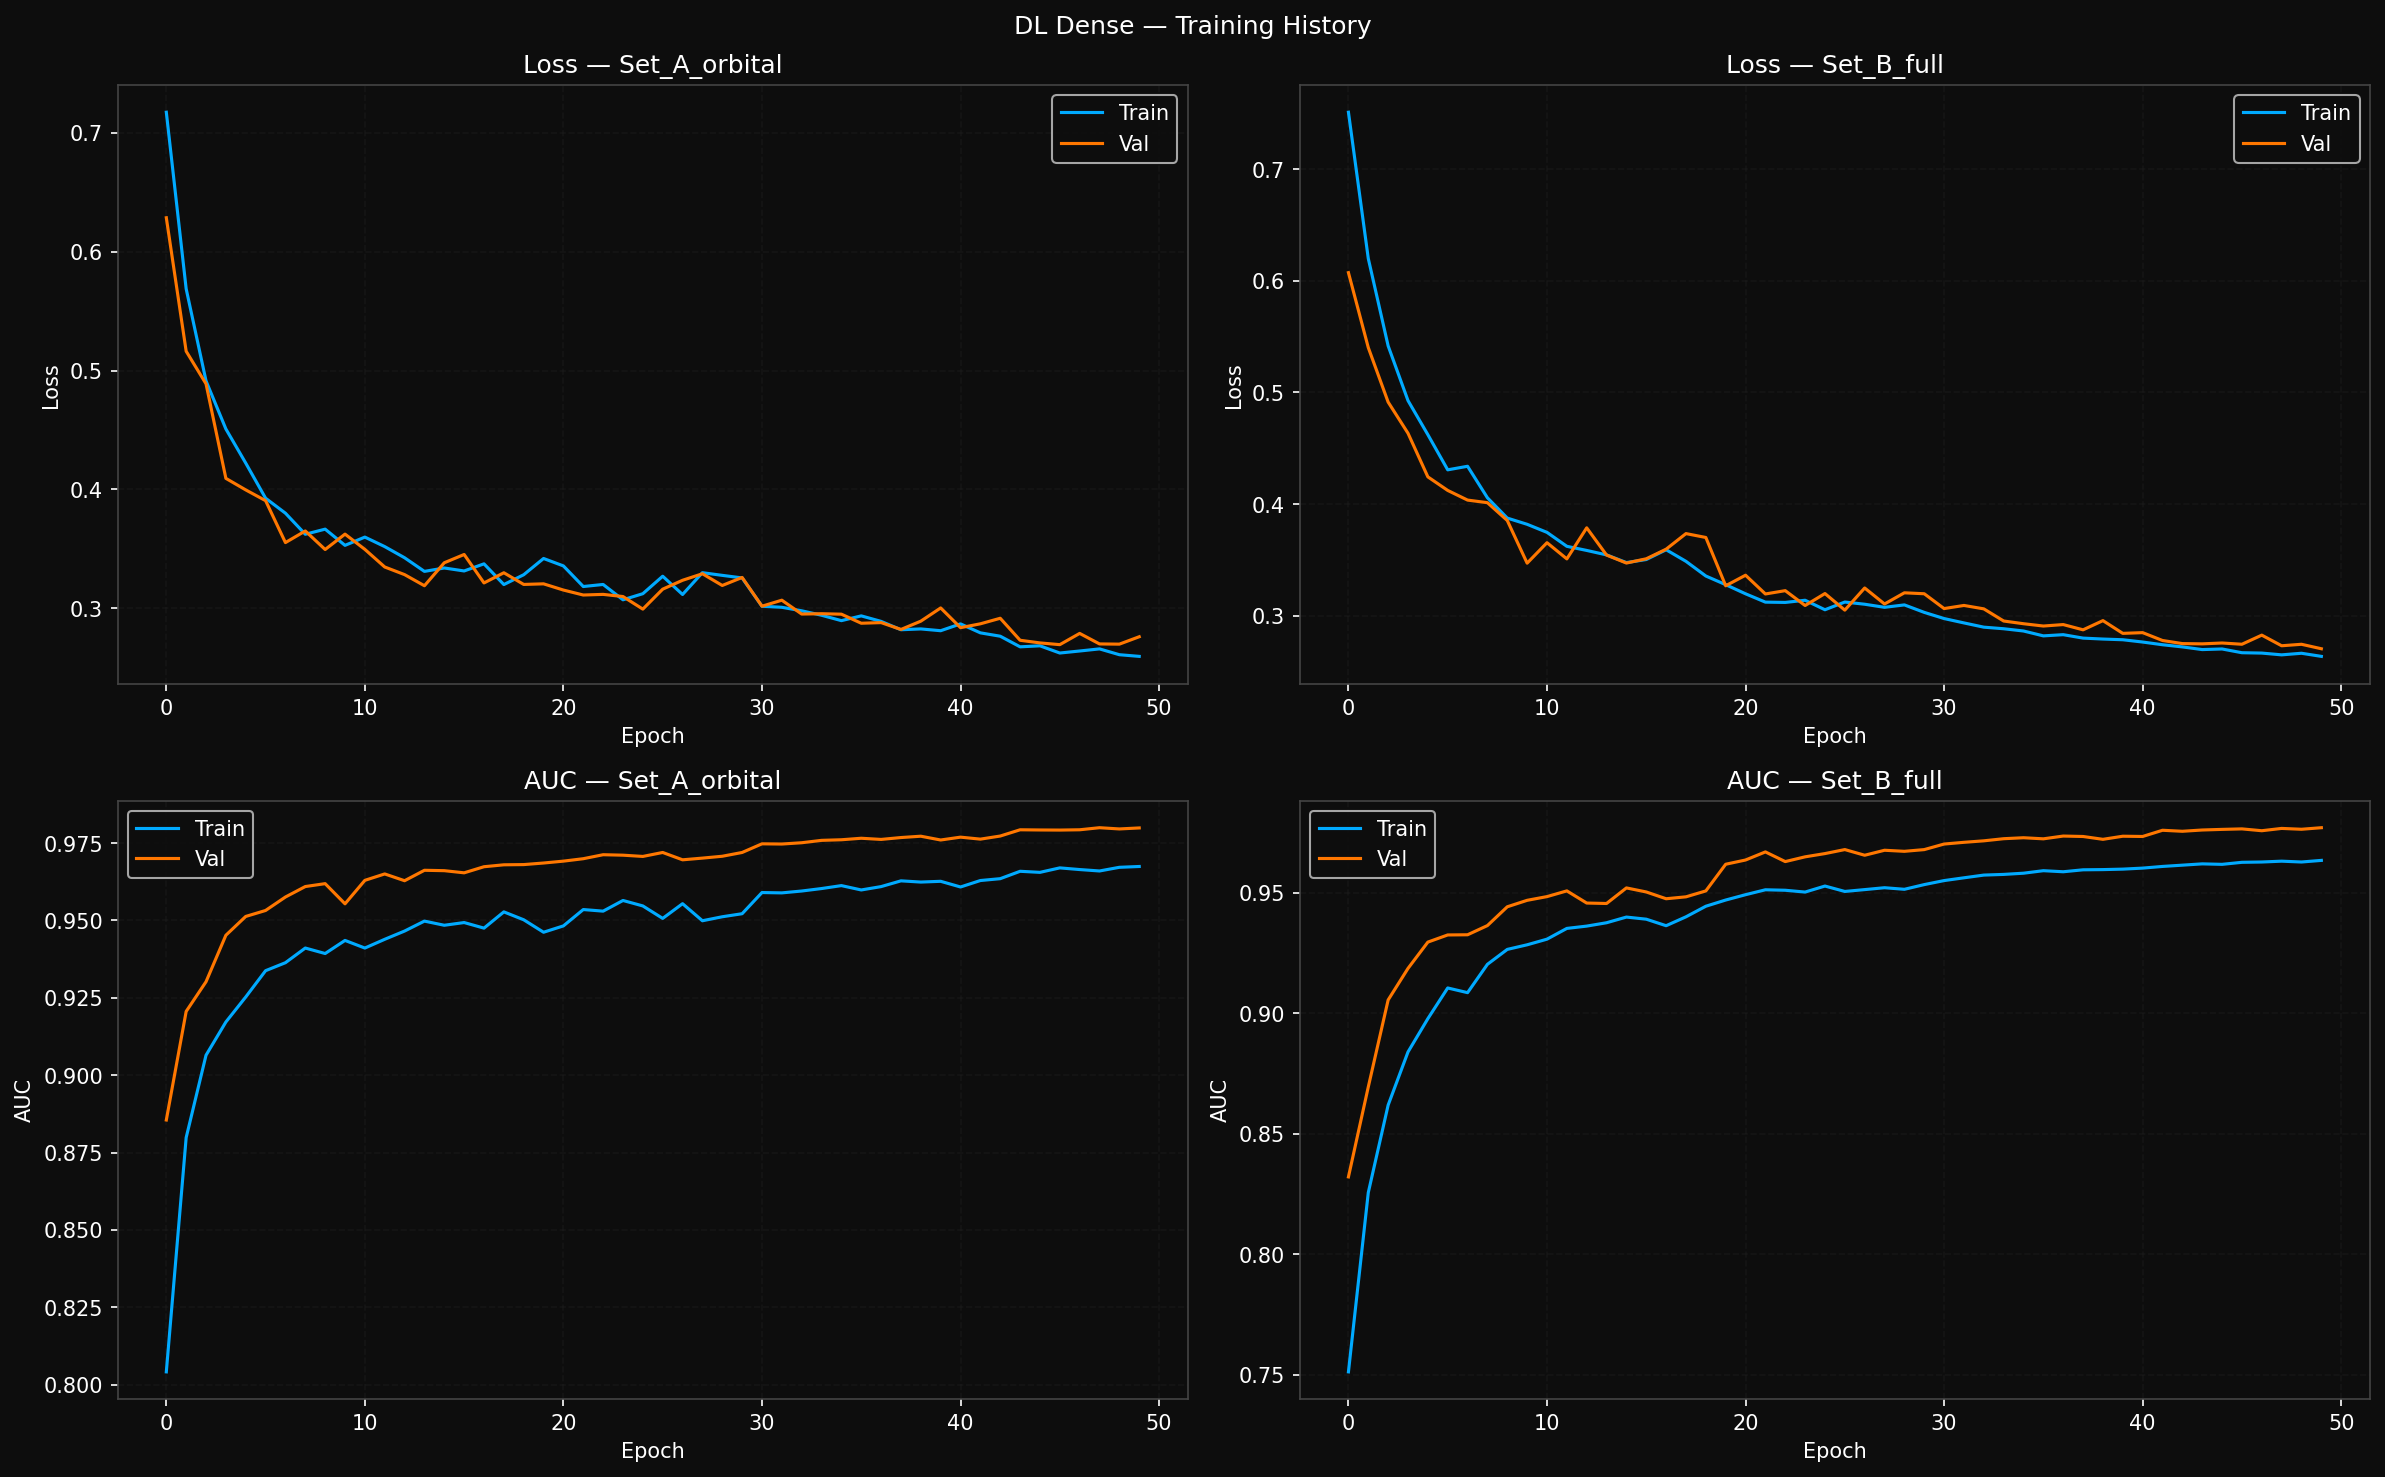

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, feat_name in enumerate(['Set_A_orbital', 'Set_B_full']):
    hist = dl_results[feat_name]['history']

    # Loss
    axes[0, col].plot(hist['loss'],     label='Train', color='#00aaff')
    axes[0, col].plot(hist['val_loss'], label='Val',   color='#ff7700')
    axes[0, col].set_title(f'Loss — {feat_name}')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()
    axes[0, col].grid(True)

    # AUC
    axes[1, col].plot(hist['auc'],     label='Train', color='#00aaff')
    axes[1, col].plot(hist['val_auc'], label='Val',   color='#ff7700')
    axes[1, col].set_title(f'AUC — {feat_name}')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('AUC')
    axes[1, col].legend()
    axes[1, col].grid(True)

plt.suptitle('DL Dense — Training History', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05a_iv_dl_history.png'), dpi=200, bbox_inches='tight')
plt.show()

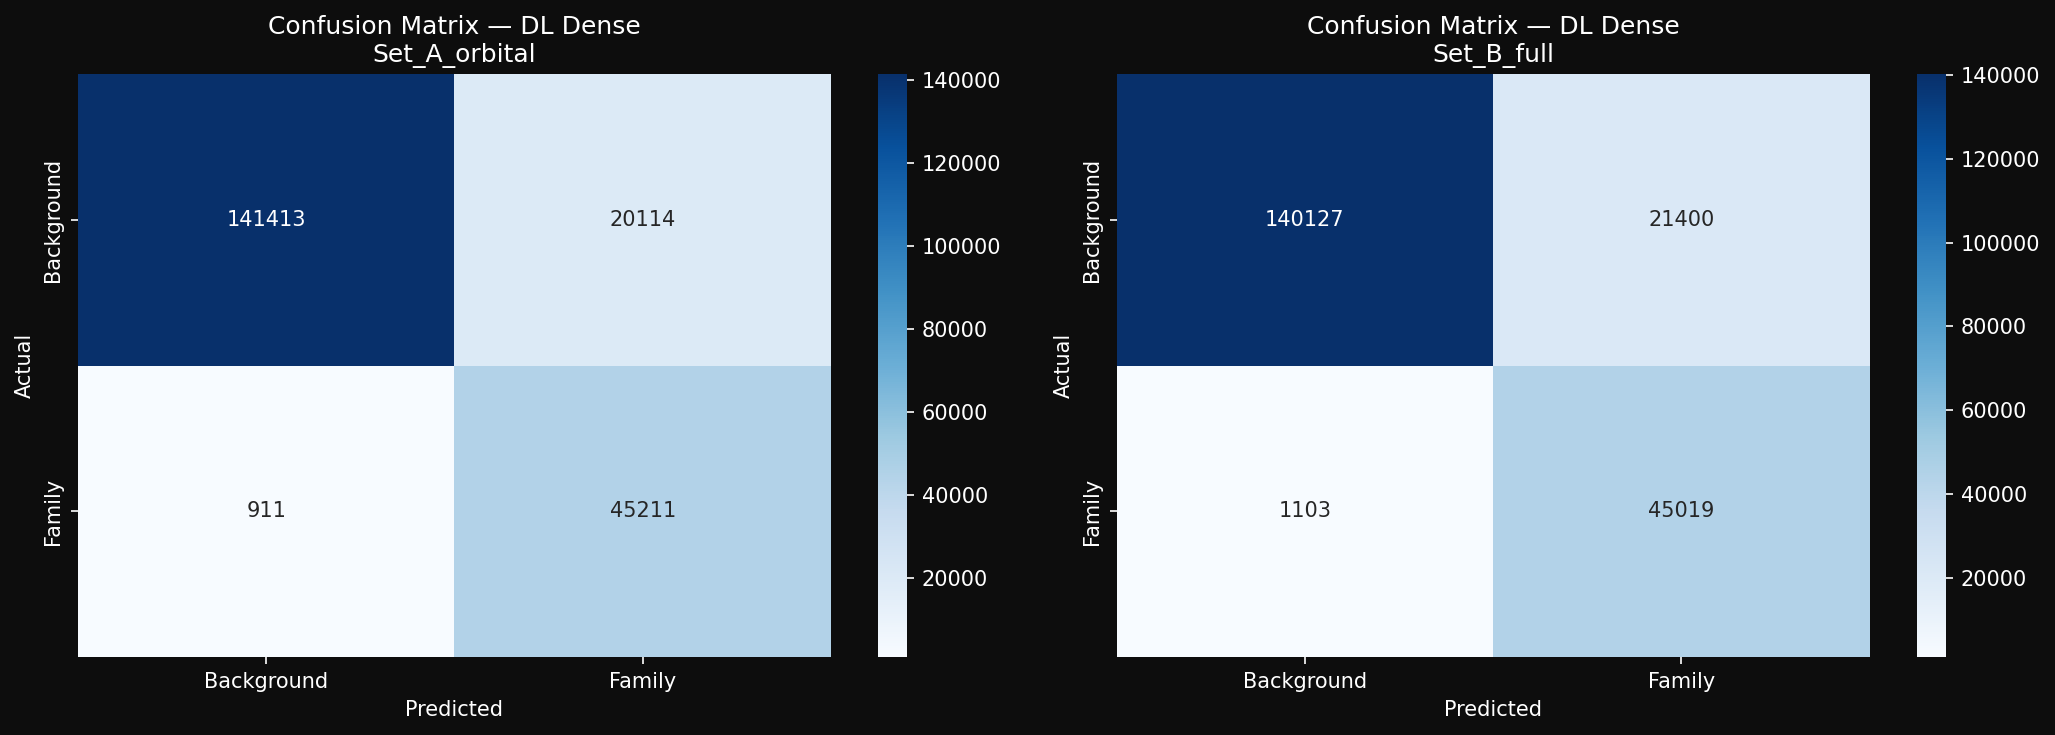

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat_name in zip(axes, ['Set_A_orbital', 'Set_B_full']):
    res = dl_results[feat_name]
    cm  = confusion_matrix(res['y_test'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Background', 'Family'],
                yticklabels=['Background', 'Family'],
                ax=ax, cbar=True)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — DL Dense\n{feat_name}')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05a_iv_dl_confusion.png'), dpi=200, bbox_inches='tight')
plt.show()

In [12]:
with open(os.path.join('data', 'results', 'classification_results', '06a_i_binary_rf_results.pkl'), 'rb') as f:
    rf_results = pickle.load(f)
with open(os.path.join('data', 'results', 'classification_results', '06a_ii_binary_svm_results.pkl'), 'rb') as f:
    svm_results = pickle.load(f)

print(f"\n{'='*80}")
print(f"{'Binary Classification — Complete Summary':^80}")
print(f"{'='*80}")
print(f"{'Model':<35} {'F1':>8} {'AUC':>8} {'Acc':>8} {'Prec':>8} {'Rec':>8}")
print(f"{'-'*80}")

# RF
for feat_name, res in rf_results.items():
    print(f"{'RF_'+feat_name:<35} {res['f1']:>8.4f} {res['auc']:>8.4f} "
          f"{res['acc']:>8.4f} {res['prec']:>8.4f} {res['rec']:>8.4f}")

# Best SVM RBF
for feat_name in ['Set_A_orbital', 'Set_B_full']:
    res = svm_results[f'{feat_name}_best']
    print(f"{'SVM_RBF_'+feat_name:<35} {res['f1']:>8.4f} {res['auc']:>8.4f} "
          f"{res['acc']:>8.4f} {res['prec']:>8.4f} {res['rec']:>8.4f}")

# DL Dense
for feat_name, res in dl_results.items():
    print(f"{'DL_Dense_'+feat_name:<35} {res['f1']:>8.4f} {res['auc']:>8.4f} "
          f"{res['acc']:>8.4f} {res['prec']:>8.4f} {res['rec']:>8.4f}")


                    Binary Classification — Complete Summary                    
Model                                     F1      AUC      Acc     Prec      Rec
--------------------------------------------------------------------------------
RF_Set_A_orbital                      0.9372   0.9960   0.9712   0.9078   0.9686
RF_Set_B_full                         0.9259   0.9944   0.9659   0.8965   0.9572
SVM_RBF_Set_A_orbital                 0.6164   0.8857   0.7642   0.4825   0.8531
SVM_RBF_Set_B_full                    0.4089   0.6198   0.4217   0.2645   0.9005
DL_Dense_Set_A_orbital                0.8113   0.9800   0.8987   0.6921   0.9802
DL_Dense_Set_B_full                   0.8000   0.9766   0.8916   0.6778   0.9761


In [13]:
save_dict = {
    feat_name: {k: v for k, v in res.items() if k not in ['scaler', 'model']}
    for feat_name, res in dl_results.items()
}

with open(os.path.join('data', 'results', 'classification_results', '06a_iii_dl_dense_results.pkl'), 'wb') as f:
    pickle.dump(save_dict, f)

print("Saved → data/results/06a_iii_dl_dense_results.pkl")

Saved → data/results/06a_iii_dl_dense_results.pkl
